In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
from tqdm import tqdm
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Create directories
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
# %% [markdown]
# ## 1. Data Preprocessing 

# %%
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    
    # Data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    # Convert image to tensor
    transforms.ToTensor(),
    
    # Normalize RGB channels
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    
    # Convert image to tensor
    transforms.ToTensor(),
    
    # Normalize RGB channels
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [4]:
# ## 2. Data Loading

# %%
full_dataset = datasets.ImageFolder("../data/raw/Training")
num_classes = len(full_dataset.classes)
print(f"Classes: {full_dataset.classes}")
print(f"Class to index: {full_dataset.class_to_idx}")

# Class distribution
class_counts = Counter(full_dataset.targets)
print("\nClass Distribution:")
for cls, count in zip(full_dataset.classes, [class_counts[i] for i in range(num_classes)]):
    print(f"  {cls}: {count}")

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_data, val_data = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
    def __len__(self):
        return len(self.dataset)

train_dataset = ApplyTransform(train_data, train_transforms)
val_dataset = ApplyTransform(val_data, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# %%


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Class Distribution:
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400

Train samples: 4480
Val samples: 1120


In [5]:

# ## RESIDUAL CNN ARCHITECTURE

class ResidualBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        self.conv_block = nn.Sequential(
            
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels)
        )
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        
        # Match dimensions if needed
        if stride != 1 or in_channels != out_channels:
            
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride
                ),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        
        residual = self.shortcut(x)
        
        out = self.conv_block(x)
        
        out += residual
        
        out = torch.relu(out)
        
        return out


class ResidualCNN(nn.Module):
    
    def __init__(self, num_classes=4):
        super(ResidualCNN, self).__init__()
        
        # Initial feature extraction
        self.initial = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Residual blocks
        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        
        # Global pooling
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        
        x = self.initial(x)
        
        x = self.layer1(x)
        
        x = self.layer2(x)
        
        x = self.layer3(x)
        
        x = self.pool(x)
        
        x = self.classifier(x)
        
        return x


# Initialize model
model = ResidualCNN(num_classes).to(device)

# Display model summary
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


ResidualCNN(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv_block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    (conv_block): Sequential(
      (0): Conv2d(64, 128, kern

In [6]:
# ## 4. Training Setup

# %%
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

# Early stopping
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_acc, model):
        if self.best_score is None or val_acc > self.best_score:
            self.best_score = val_acc
            self.counter = 0
            torch.save(model.state_dict(), '../models/residual_cnn.pth')
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=10)

print("Training Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau (patience=5)")
print(f"  Early Stopping: patience=10")



Training Configuration:
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (patience=5)
  Early Stopping: patience=10


In [7]:
# ## 5. Training Functions

# %%
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


In [8]:
# ## 6. Training Loop

# %%
num_epochs = 10
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("\n" + "=" * 60)
print("TRAINING RESIDUAL CNN")
print("=" * 60)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_acc)
    early_stopping(val_acc, model)
    
    print(f"Epoch {epoch+1:2d} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if early_stopping.early_stop:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Validation Accuracy: {max(history['val_acc']):.2f}%")

# %%



TRAINING RESIDUAL CNN
Epoch  1 | Train Loss: 0.7642 | Train Acc: 70.13% | Val Loss: 0.8793 | Val Acc: 65.54%
Epoch  2 | Train Loss: 0.5663 | Train Acc: 78.44% | Val Loss: 0.7077 | Val Acc: 72.41%
Epoch  3 | Train Loss: 0.5043 | Train Acc: 81.38% | Val Loss: 0.4714 | Val Acc: 82.86%
Epoch  4 | Train Loss: 0.4428 | Train Acc: 82.92% | Val Loss: 2.0071 | Val Acc: 46.43%
Epoch  5 | Train Loss: 0.4078 | Train Acc: 85.25% | Val Loss: 0.3552 | Val Acc: 87.14%
Epoch  6 | Train Loss: 0.3876 | Train Acc: 85.85% | Val Loss: 0.4037 | Val Acc: 84.91%
Epoch  7 | Train Loss: 0.3464 | Train Acc: 87.10% | Val Loss: 0.9648 | Val Acc: 64.38%
Epoch  8 | Train Loss: 0.3394 | Train Acc: 87.57% | Val Loss: 0.9748 | Val Acc: 71.79%
Epoch  9 | Train Loss: 0.3174 | Train Acc: 88.53% | Val Loss: 0.4832 | Val Acc: 82.68%
Epoch 10 | Train Loss: 0.3241 | Train Acc: 88.26% | Val Loss: 0.3712 | Val Acc: 86.43%

Best Validation Accuracy: 87.14%


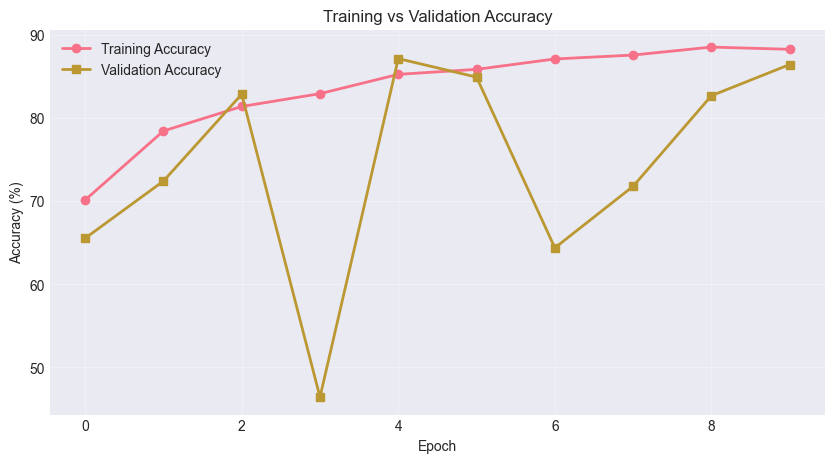

In [9]:
# ## 7. Accuracy Graph

# %%
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Training Accuracy', linewidth=2, marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/figures/accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# %%


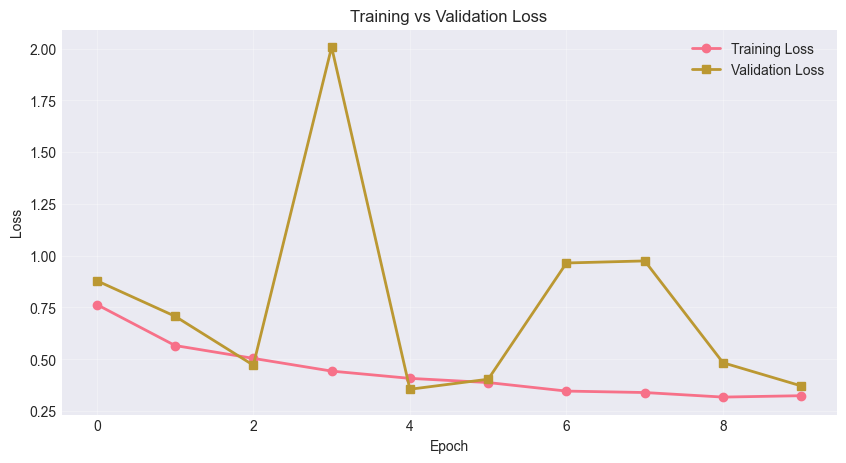

In [10]:
# ## 8. Loss Graph

# %%
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss', linewidth=2, marker='o')
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../results/figures/loss.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
# ## 9. Test Evaluation

# %%
test_dataset = datasets.ImageFolder("../data/raw/Testing", transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load best model
model.load_state_dict(torch.load('../models/residual_cnn.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# %%
# Test Accuracy
test_acc = accuracy_score(all_labels, all_preds)
print("\n" + "=" * 50)
print(f"OVERALL TEST ACCURACY: {test_acc*100:.2f}%")
print("=" * 50)

# %%
# Classification Report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


OVERALL TEST ACCURACY: 79.19%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.90      0.58      0.70       400
  meningioma       0.66      0.71      0.68       400
     notumor       0.81      0.96      0.88       400
   pituitary       0.84      0.91      0.87       400

    accuracy                           0.79      1600
   macro avg       0.80      0.79      0.79      1600
weighted avg       0.80      0.79      0.79      1600



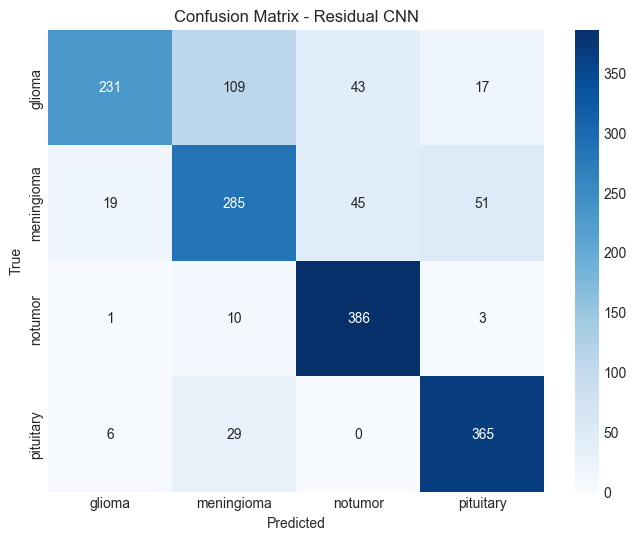

In [12]:
# ## 10. Confusion Matrix

# %%
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title('Confusion Matrix - Residual CNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('../results/figures/confusion.png', dpi=300, bbox_inches='tight')
plt.show()


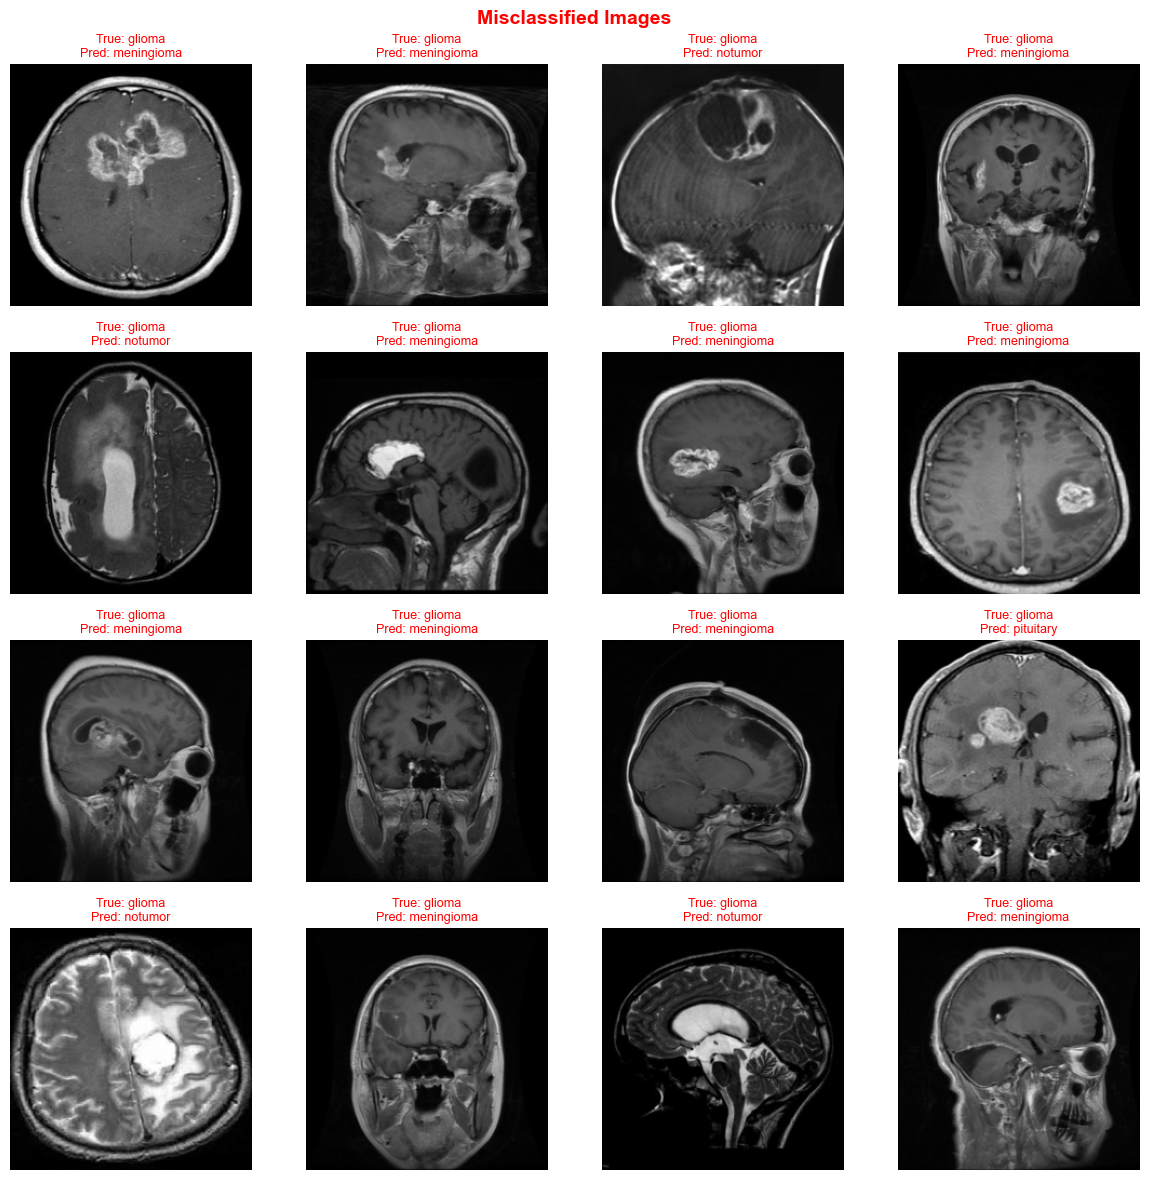

In [13]:
# ## 11. Misclassified Images

# %%
def show_misclassified(model, loader, classes, max_show=16):
    model.eval()
    wrong_images = []
    wrong_true = []
    wrong_pred = []
    
    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            _, preds = outputs.max(1)
            
            for i in range(len(images)):
                if preds[i] != labels[i]:
                    wrong_images.append(images[i])
                    wrong_true.append(labels[i].item())
                    wrong_pred.append(preds[i].item())
                if len(wrong_images) >= max_show:
                    break
            if len(wrong_images) >= max_show:
                break
    
    if wrong_images:
        rows = (len(wrong_images) + 3) // 4
        fig, axes = plt.subplots(rows, 4, figsize=(12, 3*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        for i, ax in enumerate(axes.flat):
            if i < len(wrong_images):
                img = wrong_images[i]
                img = img * 0.5 + 0.5  # Denormalize
                ax.imshow(img.permute(1, 2, 0))
                ax.set_title(f'True: {classes[wrong_true[i]]}\nPred: {classes[wrong_pred[i]]}',
                           color='red', fontsize=9)
            ax.axis('off')
        
        plt.suptitle('Misclassified Images', fontsize=14, fontweight='bold', color='red')
        plt.tight_layout()
        plt.savefig('../results/figures/misclassified.png', dpi=300, bbox_inches='tight')
        plt.show()

show_misclassified(model, test_loader, test_dataset.classes)

# %%
